In [5]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO

In [6]:
model = YOLO("yolov8n.pt")

True


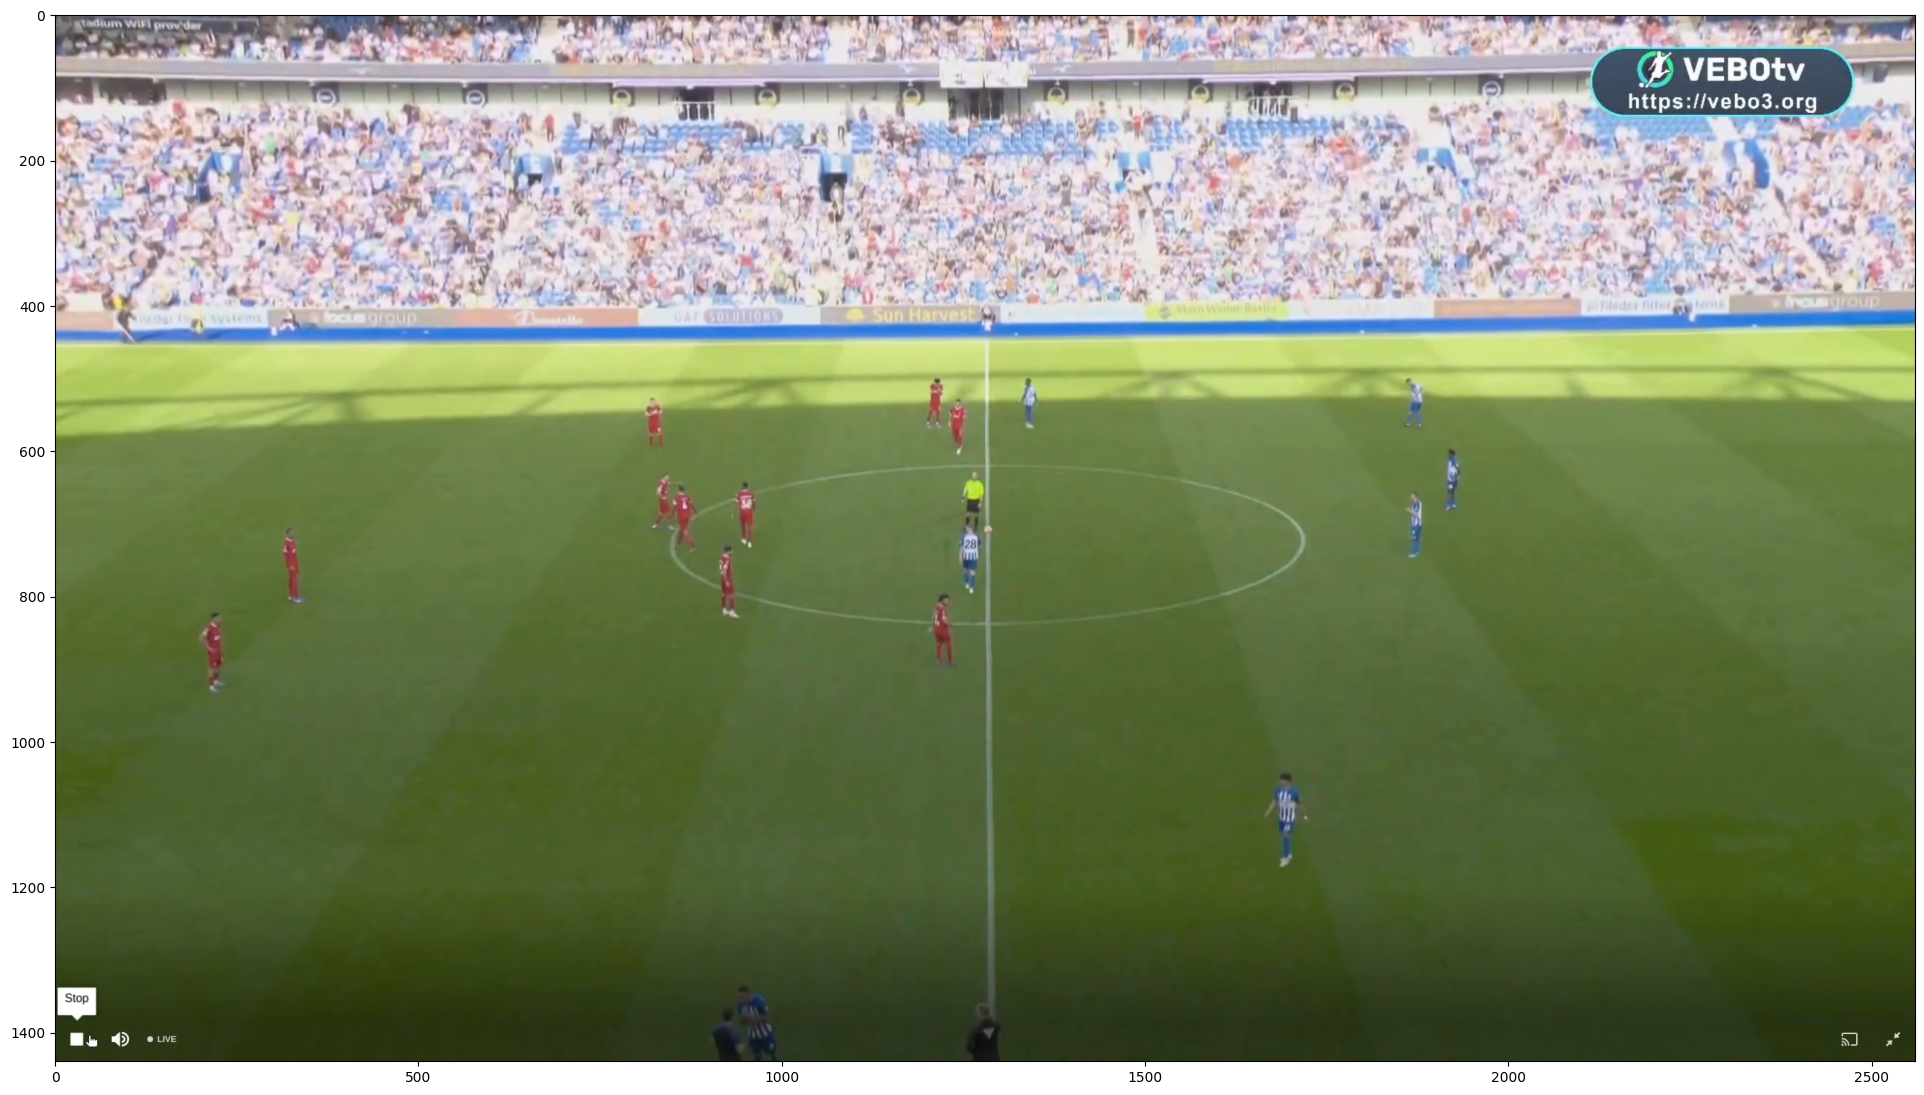

In [8]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'Liv-BHA 2nd half'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, '000000000015.png')

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])


0: 384x640 13 persons, 6.5ms
Speed: 1.8ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


Object type: tensor([0.], device='cuda:0')
[1856, 658, 1888, 749]
Object type: tensor([0.], device='cuda:0')
[1674, 1046, 1719, 1173]
Object type: tensor([0.], device='cuda:0')
[197, 821, 239, 936]
Object type: tensor([0.], device='cuda:0')
[812, 530, 838, 592]
Object type: tensor([0.], device='cuda:0')
[1203, 800, 1239, 895]
Object type: tensor([0.], device='cuda:0')
[309, 712, 343, 813]
Object type: tensor([0.], device='cuda:0')
[1856, 498, 1886, 565]
Object type: tensor([0.], device='cuda:0')
[1242, 676, 1278, 800]
Object type: tensor([0.], device='cuda:0')
[1909, 591, 1938, 684]
Object type: tensor([0.], device='cuda:0')
[1217, 500, 1256, 605]
Object type: tensor([0.], device='cuda:0')
[906, 1341, 997, 1438]
Object type: tensor([0.], device='cuda:0')
[1197, 497, 1244, 603]
Object type: tensor([0.], device='cuda:0')
[1238, 646, 1283, 800]


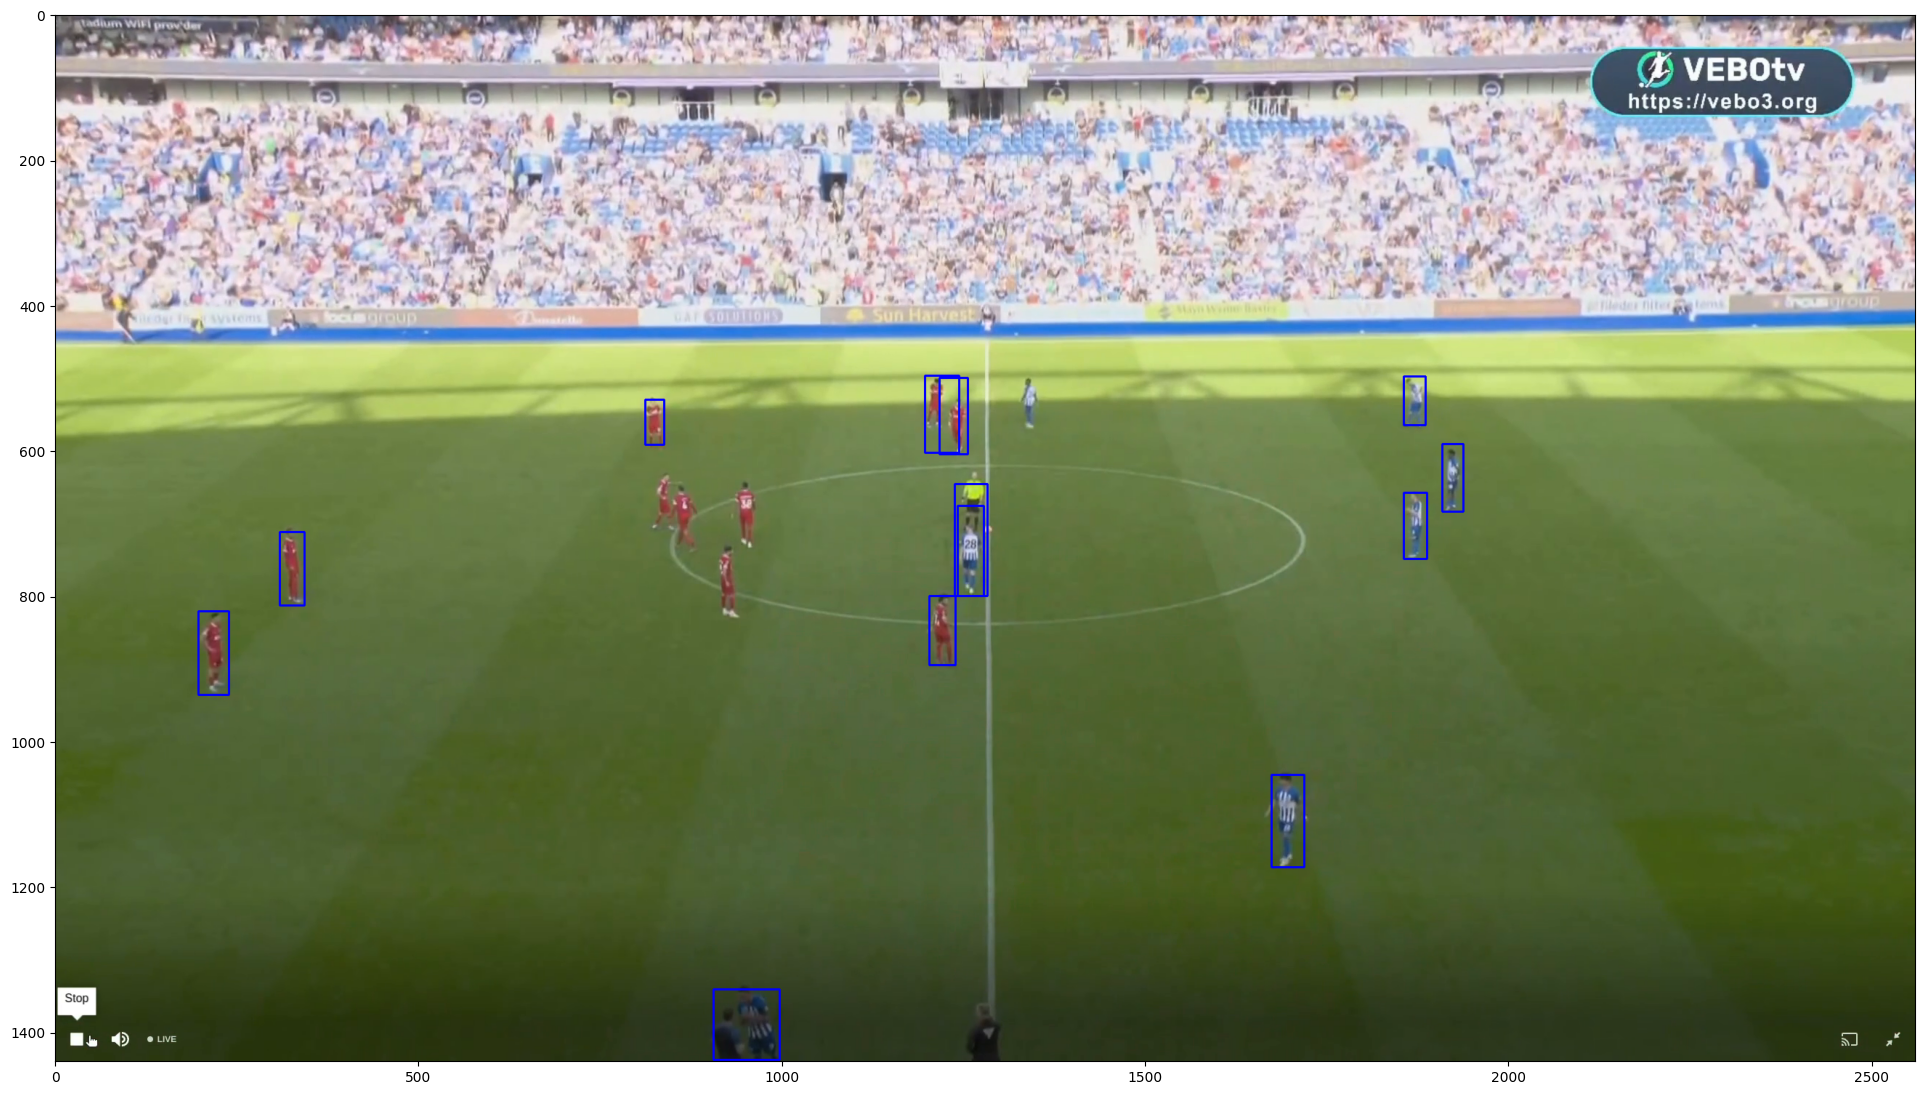

In [15]:
results = model.predict(rgb_image)

for result in results:
    boxes = result.boxes
    for box in boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        print("Object type:", box.cls)
        
        print(coord)
        (startX, startY, endX, endY) = coord
        cv2.rectangle(rgb_image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)
        
plt.figure()
plt.imshow(rgb_image[:,:,::-1])
